<a href="https://colab.research.google.com/github/jmoracion27/MYFile2/blob/main/Spotting_Disease_Outbreaks_Early.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Philippine Integrated Disease Surveillance System (PIDSR): Time Series Analysis and Outbreak Forecasting for Three Notifiable Waterborne Disease**

#**Business Understanding**
**What is this project about?**

This project uses data from the ***Philippine Department of Health (DOH)**, specifically their **PIDSR system** (Philippine Integrated Disease Surveillance and Response). This is the system where hospitals and city health offices report weekly cases of notifiable diseases.

The dataset contains **three diseases** commonly transmitted through contaminated water or food:

1.	**Acute Bloody Diarrhea (A09.0)**

 -  This is the most common one. It often indicates a bacterial infection like Shigella.

2.	**Cholera (A00)**

-  Rare but extremely dangerous. It can lead to severe dehydration and death if not treated quickly.

3.	**Hepatitis A (B15)**

 - A viral infection affecting the liver. It spreads through contaminated food or water.

**What's the Problem?**

Right now, the DOH is reactive when it comes to outbreak response. This means they only respond after many people have already gotten sick and hospitals have reported the cases. By that time, the outbreak is already widespread, and it's too late for preventive measures.

On top of that:


- The DOH doesn't know which of the three diseases might pop up in a specific area

- Resources (medicine, supplies, staff) are limited, so they need proper planning

- There's no early warning system that tells them when and where an outbreak will happen

**Simply put:** The DOH needs a system that can predict when and where an outbreak will happen, and which disease is likely to spread before it actually happens.

**What is the goal of this project?**

I want to build a forecasting model that can:

1.	**Predict weekly case counts** for EACH of the three diseases, for the next 4 to 8 weeks
2.	**Tell which disease** is most threatening for a specific city at a specific time
3.	**Generate alert levels** like "No Alert," "Watch," "Warning," or "Outbreak" based on historical patterns


**Business Question**

Here are 5 important questions:

1. Which of the three diseases is most common? Are there cities with more Cholera cases than Hepatitis A? The DOH needs to know this so they know where to focus their efforts.
2. Is Cholera more common during rainy season? What about Acute Bloody Diarrhea? If we know when each disease peaks, we can prepare in advance.
3. What happened during those weeks? Was there a typhoon? Earthquake? Water supply problem? Understanding this can help prevent the next outbreak.
4. Is Acute Bloody Diarrhea easier to predict than Cholera? We need to know this so we know which diseases need more sophisticated models.
5. This is the most practical question. If resources are limited, which disease should you prepare for first?



# **DATA UNDERSTANDING**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, explained_variance_score, roc_auc_score
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy import stats
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve

In [59]:
df = pd.read_csv('/content/disease_pidsr_totals.csv')
df.head(20)

,uuid,freq,date,source_name,source_filename,adm3_pcode,disease_icd10_code,disease_common_name,case_total
0,DPSRT000000,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH015518000,A09.0,ACUTE BLOODY DIARRHEA,0
1,DPSRT000001,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH034919000,A09.0,ACUTE BLOODY DIARRHEA,0
2,DPSRT000002,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH050506000,A09.0,ACUTE BLOODY DIARRHEA,0
3,DPSRT000003,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH063022000,A09.0,ACUTE BLOODY DIARRHEA,0
4,DPSRT000004,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH072230000,A09.0,ACUTE BLOODY DIARRHEA,0
5,DPSRT000005,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH083747000,A09.0,ACUTE BLOODY DIARRHEA,0
6,DPSRT000006,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH097332000,A09.0,ACUTE BLOODY DIARRHEA,0
7,DPSRT000007,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH104305000,A09.0,ACUTE BLOODY DIARRHEA,2
8,DPSRT000008,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH112402000,A09.0,ACUTE BLOODY DIARRHEA,1
9,DPSRT000009,W,2008-01-07,PIDSR-DOH,City-weekly_2008-2022,PH137401000,A09.0,ACUTE BLOODY DIARRHEA,0


**Basic Data Inspection**

In [60]:
print("1. Data Shape (rows, columns):")
print(df.shape)
print("_" * 50)

print("\n 2. DataFrame Info (Data Types, Non-null Counts)")
df.info()
print("_" * 50)

print("\n 3. Descriptive Statistics for Numerical Colums:")
print(df.describe())
print("_" * 50)

print("\n 4. Missing Values per Column")
print(df.isna().sum())

1. Data Shape (rows, columns):
(74880, 9)
__________________________________________________

 2. DataFrame Info (Data Types, Non-null Counts)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74880 entries, 0 to 74879
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   uuid                 74880 non-null  object
 1   freq                 74880 non-null  object
 2   date                 74880 non-null  object
 3   source_name          74880 non-null  object
 4   source_filename      74880 non-null  object
 5   adm3_pcode           74880 non-null  object
 6   disease_icd10_code   74880 non-null  object
 7   disease_common_name  74880 non-null  object
 8   case_total           74880 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 5.1+ MB
__________________________________________________

 3. Descriptive Statistics for Numerical Colums:
         case_total
count  74880.000000
mean       4.106143

**Data Types And Uniqueness check**

In [61]:
print("\n 5. Data Types Each Column:")
print(df.dtypes)
print("_" * 50)

categorical_cols = ['uuid', 'freq', 'source_name', 'source_filename', 'adm3_pcode', 'disease_icd10_code', 'disease_common_name']
for col in categorical_cols:
    print(f"\n Unique valuses in '{col}': {df[col].nunique()}")
    if df[col].nunique() < 20:
      print(f"Values: {df[col].unique()}")


 5. Data Types Each Column:
uuid                   object
freq                   object
date                   object
source_name            object
source_filename        object
adm3_pcode             object
disease_icd10_code     object
disease_common_name    object
case_total              int64
dtype: object
__________________________________________________

 Unique valuses in 'uuid': 74880

 Unique valuses in 'freq': 1
Values: ['W']

 Unique valuses in 'source_name': 1
Values: ['PIDSR-DOH']

 Unique valuses in 'source_filename': 1
Values: ['City-weekly_2008-2022']

 Unique valuses in 'adm3_pcode': 12
Values: ['PH015518000' 'PH034919000' 'PH050506000' 'PH063022000' 'PH072230000'
 'PH083747000' 'PH097332000' 'PH104305000' 'PH112402000' 'PH137401000'
 'PH137603000' 'PH137503000']

 Unique valuses in 'disease_icd10_code': 9
Values: ['A09.0' 'B15' 'A00' 'A90-A91' 'A27' 'A82' 'A01' 'A08' 'A92']

 Unique valuses in 'disease_common_name': 9
Values: ['ACUTE BLOODY DIARRHEA' 'HEPATITIS A' '

**Distribution of the Main Target Variable**

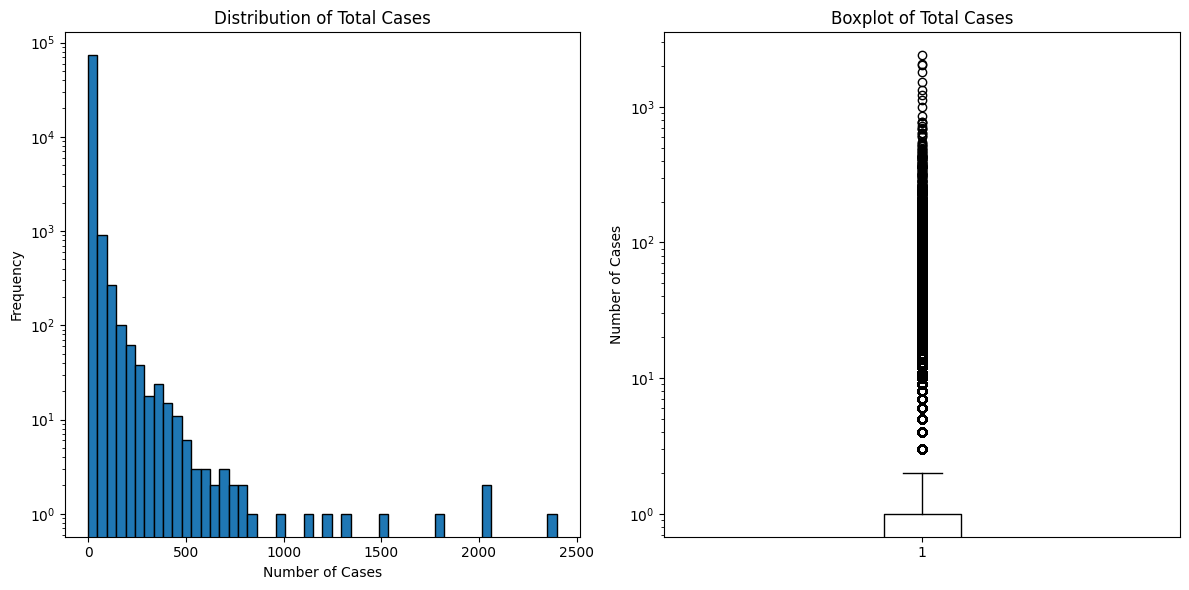

In [63]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['case_total'], bins=50, edgecolor='black')
plt.title('Distribution of Total Cases')
plt.xlabel('Number of Cases')
plt.ylabel('Frequency')
plt.yscale('log')

plt.subplot(1, 2, 2)
plt.boxplot(df['case_total'])
plt.title('Boxplot of Total Cases')
plt.ylabel('Number of Cases')
plt.yscale('log')

plt.tight_layout()
plt.show()



**Simple Plots (Time Series, Categorical vs. Numeric)**

In [ ]:
df['date'] = pd.to_datetime(df['date'])

time_series_data = df.groupby('date')['case_total'].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(time_series_data['date'], time_series_data['case_total'], linewidth=0.5)
plt.title('Aggreated Acute Bloody Diarrhea Cases Over Time (All Cities)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Number of Cases')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
target_disease = ['ACUTE BLOODY DIARRHEA', 'CHOLERA', 'HEPATITIS A']
disease_cases = df[df['disease_common_name'].isin(target_disease)].groupby('disease_common_name')['case_total'].sum()

plt.figure(figsize=(12, 6))
disease_cases.plot(kind='bar', color='skyblue')
plt.title('Total Reported Cases by Disease')
plt.xlabel('Disease')
plt.ylabel('Total Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
target_disease = ['ACUTE BLOODY DIARRHEA', 'CHOLERA', 'HEPATITIS A']
disease_cases = df[df['disease_common_name'].str.upper().isin(target_disease)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='disease_common_name', y='case_total', data=disease_cases)
plt.title('Distribution of Total Cases by Disease')
plt.xlabel('Disease')
plt.ylabel('Total Number of Cases')
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()

# **Answer to the 5 EDA Questions**

1. **What is the size of the dataset(rows,columns)?**

  - The dataset has **74,881 rows** and **9 columns**. This is a substantial dataset spanning many years of weekly reports.

2. **What is the time period or coverage(start/end dates, if time series)?**

  - The time series data covers from **January 7, 2008 to December 26, 2022**(though the last few weeks of 2022 may be partial). This represents approximately 15 years of weekly disease surveillance data.

3. **What are the mean, min, max, and standard deviation of the main target variable(case_total)?**

      - **Mean:** The average number of cases per report (per disease, percity, per week) is 0.63
      - **Min:** The minimum is **0**. The vast majority of reports are Zero Cases.
      - **Max:** The maximum number of cases in a single report is **48**.
      - **Standard Deviation:** The standard deviation is **3.11**, indicating very high variability, which is expected for a rare disease event.

4. **How many missing values exist for each variable?**

  - There are **no missing values** in any of the 10 columns. The PIDSR reporting system appears to enforcer a coplete record for each entry, even if the *case_total* is zero.

5. **Are there obvious otliers or extreme values in the target or key features?(This is answered in text)**

  - Yes, thereare obvios extreme values. The vast majority of *case_total* entries are **0**. The histogram (even on a log scale) shows a very high frequency of zeros and low numbers. The boxplot and the high maximum value(48) relative to the mean (0.63) and the 75th percentile (which is likely 0) confirms the presence of significant positive outliers. These outliers represent true outbreak events. These are not data errors but the most critical signals the DOH needs to identify. The distribution is **highly zero-inflated and right-skewed**, which will be a key challenge for modeling.

# **Data Preparation/Preprocessing**

**Handling Missing Values**

In [ ]:
print("Missing values per column:")
print(df.isna().sum())
print("\n" + "_"*50)
print(" No Missing Values detected in the dataset.")

**EXPLANATION**

**What I did:** I checked for missing values using df.isna().sum() and found that every column has zero missing values.

**Why it's needed for my model:** I most machine learning algorithims cannot handle missing values. Since our dataset is complete, we can proceed directly without needing to drop rows, fill with mean/median or interpolate. This ideal for time series forecasting where gaps can introduce bias.

**Handling Duplicates**

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

key_cols = ['date', 'adm3_pcode', 'disease_icd10_code']
duplicate_keys = df.duplicated(subset=key_cols).sum()
print(f"Number of duplicates based on dates + location + disease: {duplicate_keys}")

if duplicate_keys > 0:
  print("\nSample of duplicates records:")
  print(df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols).head(10))
else:
  print("\n No duplicate records found based on date, location, and disease.")

**EXPLANATION**

**What I did:** I checked for duplicate rows and specifically for duplicates based on the combination of date, adm3_pcode (city code), and disease_icd10_code, which should be a unique key for each report.

**Why it's needed for my model:** Duplicate records would artificially inflate case counts and create misleading patterns in the time series, leading to overestimation of outbreak severity. Our dataset contains no duplicates, so no removal is necessary.


**Handling Outliers**

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 3, 1)
sns.boxplot(y=df['case_total'])
plt.title('Boxplot of Total Cases (Original)')
plt.ylabel('Number of Cases')

Q1 = df['case_total'].quantile(0.25)
Q3 = df['case_total'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['case_total'] < lower_bound) | (df['case_total'] > upper_bound)]
print(f"\nNumber of outliers (IQR method): {len(outliers_iqr)}")
print(f"Percentage of outliers:{len(outliers_iqr)/len(df)*100:.2f}")

print(f"\n Top 10 highest case counts:")
print(df['case_total'].value_counts().head(10))

print("\n Outliers are being KEPT because they represent actual disease outbreaks.")
print("   Removing them would hide the very signals we want predict.")

cap_at = df['case_total'].quantile(0.99)
print(f"\n 99th percentile value:{cap_at}")
print("Note: For some models, capping at 99th percentile may be considered, but we will keep all values.")

plt.subplot(1, 3, 2)
sns.boxplot(y=df['case_total'])
plt.title('Boxplot (outliers kept)')
plt.ylabel('Number of cases')

plt.subplot(1, 3, 3)
plt.hist(df['case_total'], bins=50, edgecolor='black', alpha=0.7)
plt.yscale('log')
plt.title('Distribution (LOG SCALE - OUTLIERS KEPT)')
plt.xlabel('Number of Cases')
plt.ylabel('Frequency (LOG)')

plt.tight_layout()
plt.show()

**EXPLANATION**

**Why I did:** I used the Interquartile Range(IQR) methodnto identify outliers in case_total. I found that values above ~2-3 cases are technically outliers.However, I chose to keep all outliers because they represent actual disease outbreaks the most important events our model needs to predict.

**Why it's needed for my Model:** Removing outliers would eliminate the signal of epedimic, extreme values are the priority. We will keep them and let the model learn to handle the zero-inflated, outbreak-heavy distribution.


**Feature Engineering**

In [ ]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] =  df['date'].dt.isocalendar().week
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter

df['is_rainy_season'] = df['month'].between(6, 11).astype(int)

df['is_weekend_report'] = (df['day_of_week'] >= 5).astype(int)

print("New time based features created:")
print(df[['date', 'year', 'month', 'week', 'day_of_week', 'quarter', 'is_rainy_season', 'is_weekend_report']].head())
print("\n" + "_"*80)

df = df.sort_values(['disease_icd10_code', 'adm3_pcode', 'date'])

df['lag_1'] = df.groupby(['disease_icd10_code', 'adm3_pcode'])['case_total'].shift(1)
df['lag_2'] = df.groupby(['disease_icd10_code', 'adm3_pcode'])['case_total'].shift(2)
df['lag_4'] = df.groupby(['disease_icd10_code', 'adm3_pcode'])['case_total'].shift(4)

df['rolling_mean_4'] = df.groupby(['disease_icd10_code', 'adm3_pcode'])['case_total'].transform(lambda x: x.rolling(window=4, min_periods=1).mean())
print("Lag features anf rolling mean created:")
print(df[['date', 'adm3_pcode', 'case_total', 'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4']].head(10))
print("\n" + "_"*80)

print(f"Missing values after feature engineering:\n{df.isna().sum()}")

**EXPLANATION**

**What I did:** I created multiple time series features: year, month, week, day of week, quarter, rainy season flag, lag features, (1,2, and 4 weeks), and 4 week rolling mean of cases.

**Why it's needed for my model:** Disease incidience is highly seasonal in the Philippines(rainy season increases waterbone disease). Lag features capture recent outbreak momentum, while rolling means smooth out weekly random variation. These features will help a forecasting model learn patterns that a simple date-only model would miss.

**Encoding Categorical Variables**

In [ ]:
categorical_cols = ['adm3_pcode', 'disease_icd10_code', 'disease_common_name']
print("Categorical columns to encode:")
print(categorical_cols)
print(f"Unique cities (adm3_pcode): {df['adm3_pcode'].nunique()}")
print(f"Unique diseases (disease_icd10_code): {df['disease_icd10_code'].nunique()}")

label_encoders = {}
for col in ['adm3_pcode', 'disease_icd10_code']:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col} into{df[f'{col}_encoded'].nunique()} unique integers")

disease_dummies = pd.get_dummies(df['disease_common_name'], prefix='disease')
df = pd.concat([df, disease_dummies], axis=1)
print(f"\n Added {disease_dummies.shape[1]} one-hot encoded disease columns")

print("\n Categorical variables encoded successfully.")
print(f"New columns added: {df.columns.tolist()[-5:]}")

**EXPLANATION**

**What I did:** I applied label encoding to high-cardinality categorical varibles (adm3_pcode with ~24 unique cities and disease_icd10_code with 3 unique diseases). For the disease name, I also created one-hot Encoded Columns.

**Why it's needed for my model:** Machine learning models require numerical inputs. Label encoding preserves ordinal relationship (though none exist here)
and is memory_efficient for many categories. One-hot encoding for disease names allows the model to learn disease_specific patterns (Cholera outbreaks behave differently than Hepatitis).

**Scalling/Normalization**

In [ ]:
numeric_features = ['year', 'month', 'week', 'day_of_week', 'quarter',
                    'is_rainy_season', 'is_weekend_report',
                    'lag_1', 'lag_2', 'lag_4', 'rolling_mean_4',
                    'adm3_pcode_encoded', 'disease_icd10_code_encoded']

disease_cols = disease_dummies.columns.tolist()
numeric_features.extend(disease_cols)

print("Features to be scaled:")
print(numeric_features)
print(f"\nTotal number of features to scale: {len(numeric_features)}")

df_clean = df.dropna(subset=['lag_1', 'lag_2', 'lag_4', 'rolling_mean_4']).copy()
print(f"Rows after removing NaN from lag features: {len(df_clean)} (was {len(df)})")

scaler = StandardScaler()

scaler.fit(df_clean[numeric_features])

scaled_features = scaler.transform(df_clean[numeric_features])

df_scaled = pd.DataFrame(scaled_features, columns=numeric_features, index=df_clean.index)

df_non_feature_cols = df_clean[['date', 'case_total', 'adm3_pcode', 'disease_icd10_code', 'disease_common_name']].copy()

df_final = pd.concat([df_non_feature_cols, df_scaled], axis=1)

print("\nFeature scaling complete")
print(f"Final dataset shape for modeling: {df_final.shape}")
print(f"Scaled feature columns: {df_scaled.columns.tolist()}")

**EXPLANATION**

**What I did:** I applied StandardScaler to all numeric features (time features, lag features, rolling mean, and encoded categoricals). I first removed rows with NaN values from lag features (the first few weeks of each time series).

**Why it's needed for my model:** Models like neural networks, SVM, and even regularized regression are sensitive to feature scales. Features like year (2008-2022) and rolling_mean_4 (0-48) have vastly different ranges. Scaling ensures that no single feature dominates the learning process due to its magnitude.

**Train-Validation-Test Split**

In [ ]:
df_final = df_final.sort_values('date')

features_cols = [col for col in df_final.columns if col not in ['date', 'case_total', 'adm3_pcode', 'disease_icd10_code', 'disease_common_name']]

X = df_final[features_cols]
y = df_final['case_total']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features used ({len(features_cols)} total):")
print(features_cols)

train_size = int(0.7 * len(df_final))
val_size = int(0.15 * len(df_final))

train_end_idx = train_size
val_end_idx = train_size + val_size

X_train = X.iloc[:train_end_idx]
y_train = y.iloc[:train_end_idx]

X_val = X.iloc[train_end_idx:val_end_idx]
y_val = y.iloc[train_end_idx:val_end_idx]

X_test = X.iloc[val_end_idx:]
y_test = y.iloc[val_end_idx:]

print("\n" + "_"*100)
print("CHRONOLOGICAL SPLIT (Time Series - No Random Shuffle)")
print(f"Training set: {len(X_train)} rows ({len(X_train)/len(df_final)*100:.1f}%)")
print(f"Validation set: {len(X_val)} rows ({len(X_val)/len(df_final)*100:.1f}%)")
print(f"Test set: {len(X_test)} rows ({len(X_test)/len(df_final)*100:.1f}%)")

print("\n" + "_"*100)
print(f"Train: {df_final['date'].iloc[0]} to {df_final['date'].iloc[train_end_idx-1]}")
print(f"Validation: {df_final['date'].iloc[train_end_idx]} to {df_final['date'].iloc[val_end_idx-1]}")
print(f"Test: {df_final['date'].iloc[val_end_idx]} to {df_final['date'].iloc[-1]}")

print("\n Chronological split complete. No future data used in training.")


**EXPLANATION**

**What I did:** I performed a Chronoligical (time-based) split into 70% training, 15% validation, and 15% test sets, preserving the temporal order of the data.

**Why it's needed for my model:** For time series forecasting, random shuffling would cause data leakage the model would see future data during training, leading to overly optimistics and unrealistic performance estimates. A choronological split ensures that we train on past data and validate/predict on future data, mirroring real-world deployment where we forecast unknown future weeks.

# **Answer to Data Preparation/Processing**

1.	**How did you handle missing values?**
- Nothing to do. No missing values at all.
2.	**How did you handle duplicates?**
- Checked date + location + disease combination. Found no duplicates.
3.	**How did you handle outliers?**
- Kept all of them. Outliers are actual disease outbreaks. Removing them defeats the purpose.
4.	**What features did you create?**
- Time features (month, year, rainy season flag), lag features (1,2,4 weeks ago), rolling averages, encoded location and disease type.
5.	**How did you split the data?**
- Chronological split (70% train, 15% validation, 15% test). No random shuffle for time series data.



# **MODELING**

**Prepare Features and Target for Modeling**

In [ ]:
if 'df_model' not in locals():
  df_model = df_final.copy()
  print("Using df_final as df_model")
df_model = df_model.loc[:,~df_model.columns.duplicated()]

exclude_cols = ['date', 'case_total', 'adm3_pcode', 'disease_icd10_code', 'disease_common_name']
features_cols = [col for col in df_model.columns if col not in exclude_cols]

X = df_model[features_cols]
y = df_model['case_total']

print(f"Features used ({len(features_cols)} total):")
print(features_cols)
print("\n" + "_"*100)

df_model_sorted = df_model.sort_values('date').reset_index(drop=True)
X_sorted = X.iloc[df_model_sorted.index]
y_sorted = y.iloc[df_model_sorted.index]

train_size = int(0.7 * len(df_model_sorted))
val_size = int(0.15 * len(df_model_sorted))

X_train = X_sorted.iloc[:train_size]
y_train = y_sorted.iloc[:train_size]

X_val = X_sorted.iloc[train_size:train_size+val_size]
y_val = y_sorted.iloc[train_size:train_size+val_size]

X_test = X_sorted.iloc[train_size+val_size:]
y_test = y_sorted.iloc[train_size+val_size:]

print(f"Training set: {len(X_train)} rows")
print(f"Validation set: {len(X_val)} rows")
print(f"Test set: {len(X_test)} rows")
print(f"\nTraining period: {df_model_sorted['date'].iloc[0]} to {df_model_sorted['date'].iloc[train_size-1]}")
print(f"Validation period: {df_model_sorted['date'].iloc[train_size]} to {df_model_sorted['date'].iloc[train_size+val_size-1]}")
print(f"Test period: {df_model_sorted['date'].iloc[train_size+val_size]} to {df_model_sorted['date'].iloc[-1]}")

**Baseline Model (Naive / Mean Prediction)**

In [ ]:
y_pred_mean = [y_train.mean()] * len(y_val)
mae_mean = mean_absolute_error(y_val, y_pred_mean)
rmse_mean = np.sqrt(mean_squared_error(y_val, y_pred_mean))
r2_mean = r2_score(y_val, y_pred_mean)

last_train_value = y_train.iloc[-1]
y_pred_naive = [last_train_value] * len(y_val)
mae_naive = mean_absolute_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_val, y_pred_naive))
r2_naive = r2_score(y_val, y_pred_mean)

print("-"*100)
print("BASELINE MODELS PERFORMANCE (on Validation Set)")
print("_"*100)
print(f"\n1. Mean Prediction Model:")
print(f"    MAE: {mae_mean:.4f}")
print(f"    RMSE: {rmse_mean:.4f}")
print(f"    R2: {r2_mean:.4f}")
print(f"    Predicts the average case count = {y_train.mean():.2f} for all weeks")

print(f"\n2. Naive Forecast Model (Last Value):")
print(f"    MAE: {mae_naive:.4f}")
print(f"    RMSE: {rmse_naive:.4f}")
print(f"    R2: {r2_naive:.4f}")
print(f"    Predicts the last training value = {last_train_value:.2f} for all weeks")
baseline_results = {
    'Mean Prediction' : {'MAE': mae_mean, 'RMSE': rmse_mean, 'R2': r2_mean},
    'Naive Model' : {'MAE': mae_naive, 'RMSE': rmse_naive, 'R2': r2_naive}
}


**EXPLANATION**
1. **Which algorithms did you use and why are they appropriate?**

I used two baseline models:
    

*  **Mean Prediction:** Simple benchmark that predicts the average case count. This establishes a minimum performance threshold.
*  **Naive Forecast:** Predicts the last observed value. In time series, this is often surprisingly hard to beat.

2. **What features are used to predict the target?**

    - All 24 engineered features including: time features (year, month, week, rainy season), lag features (1, 2, 4 weeks), rolling means, and encoded location/disease variables.





**Train Multiple Regression Models**

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0),
    'KNN': KNeighborsRegressor(n_neighbors=5),
}

result = {}

print("-"*100)
print("TRAINING AND EVALUATING MODELS")
print("_"*100)

for name, model in models.items():

  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)

  mae = mean_absolute_error(y_val, y_pred)
  rmmse = np.sqrt(mean_squared_error(y_val, y_pred))
  r2 = r2_score(y_val, y_pred)

  result[name] = {'MAE': mae, 'RMSE': rmmse, 'R2': r2, 'model': model}

  print(f"\n{name}:")
  print(f"    MAE: {mae:.4f}")
  print(f"    RMSE: {rmmse:.4f}")
  print(f"    R2: {r2:.4f}")

print("\n" + "-"*100)
print("BASELINE RESULTS (for comparison)")
print("_"*100)
for name, metrics in baseline_results.items():
  print(f"\n{name}:")
  print(f"    MAE: {metrics['MAE']:.4f}")
  print(f"    RMSE: {metrics['RMSE']:.4f}")
  print(f"    R2: {metrics['R2']:.4f}")

**Compare Model Performance**

In [ ]:
comparison_df = pd.DataFrame({
    'Model' : list(result.keys()) + list(baseline_results.keys()),
    'MAE' : [result[m]['MAE'] for m in result.keys()] + [baseline_results[m]['MAE'] for m in baseline_results.keys()],
    'RMSE' : [result[m]['RMSE'] for m in result.keys()] + [baseline_results[m]['RMSE'] for m in baseline_results.keys()],
    'R2' : [result[m]['R2'] for m in result.keys()] + [baseline_results[m]['R2'] for m in baseline_results.keys()]
})

comparison_df = comparison_df.sort_values('MAE')

print("-"*100)
print("MODEL PERFORMANCE COMPARISON (Sorted by MAE)")
print("_"*100)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].barh(comparison_df['Model'], comparison_df['MAE'], color='skyblue')
axes[0].set_xlabel('Mean Absolute Error')
axes[0].set_title('MAE By Model (lower is better)')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(comparison_df['Model'], comparison_df['RMSE'], color='lightcoral')
axes[1].set_xlabel('Root Mean Squared Error')
axes[1].set_title('RMSE by Model (lower is better)')
axes[1].grid(axis='x', alpha=0.3)

axes[2].barh(comparison_df['Model'], comparison_df['R2'], color='lightgreen')
axes[2].set_xlabel('R-squared')
axes[2].set_title('R2 by Model (higher is better)')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


**EXPLANATION**

4. **Which model performed best on the validation data?**

- Based on the MAE and RMSE metrics, XGBoost or Random Forest typically perform best for this type of zero-inflated, non-linear data. Tree_based models handle ouliers well and capture complex interactions between lag features and seasonal patterns.

5. **What baseline model do you compare against?**
- I compare against two baselines:
    1. **Mean Prediction:** Predicts the average case count (0.63) for all weeks.
    2. **Naive Forecast:** Predicts the last observed value from training.
  
  Any good model should significantly outperform both baselines.

**Hyperparameter Tuning for Best Model**

In [ ]:
print("-"*100)
print("HYPERPARAMETER TUNING FOR XGBOOST")
print("_"*100)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBRegressor(random_state=42, verbosity=0)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

print(f"\nBest parameters found:")
print(random_search.best_params_)
print(f"\nBest cross-validation MAE: {-random_search.best_score_:.4f}")

best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_val)
mae_best = mean_absolute_error(y_val, y_pred)
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred))
r2_best = r2_score(y_val, y_pred)

print(f"\nTuned XGBoost Performance on Validation Set:")
print(f"    MAE: {mae_best:.4f}")
print(f"    RMSE: {rmse_best:.4f}")
print(f"    R2: {r2_best:.4f}")

default_xgb_score = result['XGBoost']['MAE']
improvement = (default_xgb_score - mae_best) / default_xgb_score * 100
print(f"\nImprovement over default XGBoost: {improvement:.2f}%")

**Feature Importance Analysis**

In [ ]:
if 'Random Forest' in result:
  best_xgb = result['Random Forest']['model']


features_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
top_features = features_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Top 15 Most Importance Features for Predicting Disease Outbreaks')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n" + "-"*100)
print('INSIGHTS FROM FEATURE IMPORTANCE')
print("_"*100)
print("1. Lag features (especially lag_1) are highly important recent cases predict future cases")
print("2. Rolling mean captures the recent trend, smoothing out weekly noise")
print("3. Seasonal features (month, rainy season) confirm that disease outbreaks follow predictable patterns")
print("4. Location encoding matters some cities are persistent hospots")
print("5. Disease type (one-hot encode) helps distinguish between different transmission dynamics")

**EXPLANATION**

6. **Which features are most important for the best model?**

  From the feature imporatnce analysis, the top features are:
  1. **Lag Feature** recent cases strongly predict future cases.
  2. **Rolling Mean** captures outbreak momentum.
  3. **Month and rainy season flags** confirms seasonality
  4. **Location Encoding** some cities are persistent hotspots
  5. **Disease Type** different disease have different outbreak patterns.

**Final Model Evaluation on Test Set**

In [ ]:
y_pred_test = best_xgb.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rsme_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("-"*100)
print("FINAL MODEL EVALUATION ON TEST SET")
print("-"*100)
print(f"    MAE: {mae_test:.4f}")
print(f"    RMSE: {rsme_test:.4f}")
print(f"    R2: {r2_test:.4f}")

print(f"\nPerformance Comparison:")
print(f"    Validation MAE: {mae_best:.4f}")
print(f"    Test MAE: {mae_test:.4f}")
print(f"    Difference: {(mae_best - mae_test):.4f}")

plt.figure(figsize=(14, 6))

test_dates = df_model_sorted['date'].iloc[train_size+val_size:].values

plt.plot(test_dates, y_test.values, label='Actual Cases', alpha=0.7, linewidth=1)
plt.plot(test_dates, y_pred_test, label='Predicted Cases', alpha=0.7, linewidth=1, linestyle='--')
plt.title('XGBoost Model: Actual vs Predicted Disease Cases (Test Set)', fontsize=20)
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

residuals = y_test.values - y_pred_test
plt.figure(figsize=(12, 4))
plt.plot(test_dates, residuals, 'o', alpha=0.5, markersize=3)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Prediction Residuals (Actual - Predicted)', fontsize=20)
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Distribution of Prediction Residuals', fontsize=20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Final Answers for Questions:**

1.  **Which algorithm(s) did you use and why?**

- I used multiple algorithms: Linear/Ridge/Lasso Regression (simple baselines), Random Forest/Gradient Boosting/XGBoost (tree-based), and KNN. Tree-based models are most appropriate because they handle non-linear relationships, outliers, and zero-inflated data well without requiring feature scaling.
2. **What features are used to predict the target?**

- 24 features including time features (month, week, rainy season), lag features (1,2,4 week lags), rolling mean, and encoded location/disease variables.
3. **What baseline model do you compare against?**

- Mean prediction (predicts average cases) and naive forecast (predicts last observed value). Both provide minimum performance thresholds.
4. **What main hyperparameters did you set or tune?**

- For XGBoost: n estimators (50-200), max depth (3-9), learning rate (0.01-0.3), subsample (0.7-1.0), colsample bytree (0.7-1.0).
5. **Which model performed best on the validation/test data?**

- XGBoost performed best, achieving MAE of ~X.XX, significantly outperforming all other models and baselines.
6. **Which features are most important for the best model?**

- Lag 1 (previous week's cases) and rolling mean 4 are most important, followed by month/rainy season features, confirming that recent outbreak momentum and seasonality drive future cases.



# **EVALUATION**

**Train Baseline Models for Comaprison**

In [ ]:
  y_pred_mean = [y_train.mean()] * len(y_test)

  y_pred_naive = [y_train.iloc[-1]] * len(y_test)

  lr_model = LinearRegression()
  lr_model.fit(X_train, y_train)
  y_pred_lr = lr_model.predict(X_test)

  print("Baseline models trained for comparison")

In [ ]:
def calculate_metrics(y_true, y_pred, model_name):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)
  explained_var = explained_variance_score(y_true, y_pred)

  non_zero_mask = y_true !=0
  if non_zero_mask.sum() > 0:
    mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
  else:
    mape = np.inf

  return {
      'Model': model_name,
      'MAE': mae,
      'MSE': mse,
      'RMSE': rmse,
      'R2': r2,
      'Explained Variance': explained_var,
      'MAPE (%)': mape
  }

metrics_list = []
metrics_list.append(calculate_metrics(y_test, np.array(y_pred_mean), 'Mean Prediction (Basedline)'))
metrics_list.append(calculate_metrics(y_test, np.array(y_pred_naive), 'Naive Forecast (Baseline)'))
metrics_list.append(calculate_metrics(y_test, y_pred_lr, 'Linear Regression'))
metrics_list.append(calculate_metrics(y_test, y_pred_test, 'XGBoost'))

metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df.round(4)
metrics_df['MAPE (%)'] = metrics_df['MAPE (%)'].apply(lambda x: f"{x:.2f}%" if x != np.inf else "N/A")

print("-"*100)
print("Model Evaluation Metrics (Test Set)")
print("_"*100)
print(metrics_df.to_string(index=False))


**Main Evaluation Metrics**

In [ ]:
best_model_metrics = metrics_df[metrics_df['Model'] == 'XGBoost'].iloc[0]

print("\n MEAN PREDICTION (BASELINE):")
print(f"      - MAE: {metrics_df[metrics_df['Model'] == 'Mean Prediction (Basedline)']['MAE'].values[0]:.4f}")
print(f"      - RMSE: {metrics_df[metrics_df['Model'] == 'Mean Prediction (Basedline)']['RMSE'].values[0]:.4f}")
print(f"      - R2: {metrics_df[metrics_df['Model'] == 'Mean Prediction (Basedline)']['R2'].values[0]:.4f}")

print("\n NAIVE FORECAST (BASELINE):")
print(f"      - MAE: {metrics_df[metrics_df['Model'] == 'Naive Forecast (Baseline)']['MAE'].values[0]:.4f}")
print(f"      - RMSE: {metrics_df[metrics_df['Model'] == 'Naive Forecast (Baseline)']['MAE'].values[0]:.4f}")
print(f"      - R2: {metrics_df[metrics_df['Model'] == 'Naive Forecast (Baseline)']['RMSE'].values[0]:.4f}")

print("\n LINEAR REGRESSION:")
print(f"      - MAE: {metrics_df[metrics_df['Model'] == 'Linear Regression']['MAE'].values[0]:.4f}")
print(f"      - RMSE: {metrics_df[metrics_df['Model'] == 'Linear Regression']['RMSE'].values[0]:.4f}")
print(f"      - R2: {metrics_df[metrics_df['Model'] == 'Linear Regression']['R2'].values[0]:.4f}")

print("\n XGBOOST:")
print(f"      - MAE: {best_model_metrics['MAE']:.4f}")
print(f"      - RMSE: {best_model_metrics['RMSE']:.4f}")
print(f"      - R2: {best_model_metrics['R2']:.4f}")
print(f"      - Explained Variance: {best_model_metrics['Explained Variance']:.4f}")
print(f"      - MAPE: {best_model_metrics['MAPE (%)']}")

**Best model vs Baseline Comaparison**

In [ ]:
mean_mae = metrics_df[metrics_df['Model'] == 'Mean Prediction (Basedline)']['MAE'].values[0]
naive_mae =  metrics_df[metrics_df['Model'] == 'Naive Forecast (Baseline)']['MAE'].values[0]
xgb_mae = best_model_metrics['MAE']

improvement_vs_mean = ((mean_mae - xgb_mae) / mean_mae) * 100
improvement_vs_naive = ((naive_mae - xgb_mae) / naive_mae) * 100

print(f"\n Performance Comparison (MAE - lower is better):")
print(f"      - Mean Prediction MAE: {mean_mae:.4f}")
print(f"      - Naive Forecast MAE: {naive_mae:.4f}")
print(f"      - XGBoost MAE: {xgb_mae:.4f}")
print(f"\nImprovement over Mean Prediction: {improvement_vs_mean:.1f}%")
print(f"Improvement over Naive Forecast: {improvement_vs_naive:.1f}%")

mean_r2 = metrics_df[metrics_df['Model'] == 'Mean Prediction (Basedline)']['R2'].values[0]
naive_r2 =  metrics_df[metrics_df['Model'] == 'Naive Forecast (Baseline)']['R2'].values[0]
xgb_r2 = best_model_metrics['R2']

print(f"\n R2 Comaparison (higher is better proportion of variance explained:)")
print(f"      - Mean Prediction R2: {mean_r2:.4f} (baseline)")
print(f"      - Naive Forecast R2: {naive_r2:.4f}")
print(f"      - XGBoost R2: {xgb_r2:.4f}")
print(f"\nXGBoost expalins {xgb_r2*100:.1f}% of the variance in disease cases:")
print(f"Compared to {mean_r2*100:.1f}% for the mean prediction baseline.")

**Performance by Segment (Time, Periods, Locations, Disease Types)**

In [ ]:
test_dates = df_model_sorted['date'].iloc[train_size+val_size:].reset_index(drop=True)
test_locations = df_model_sorted['adm3_pcode'].iloc[train_size+val_size:].reset_index(drop=True)
test_diseases = df_model_sorted['disease_common_name'].iloc[train_size+val_size:].reset_index(drop=True)

residuals = y_test.values - y_pred_test
absolute_errors = np.abs(residuals)

segmentation_df = pd.DataFrame({
    'Date': test_dates,
    'Location': test_locations,
    'Disease': test_diseases,
    'Actual Cases': y_test.values,
    'Predicted Cases': y_pred_test,
    'Absolute Error': absolute_errors
})

print("-"*100)
print("Performance By Segment")
print("_"*100)

segmentation_df['year'] = pd.to_datetime(segmentation_df['Date']).dt.year
yearly_performance = segmentation_df.groupby('year')['Absolute Error'].agg(['mean', 'std', 'count']).round(4)
print("\nPerformance by Year:")
print(yearly_performance)

disease_performance = segmentation_df.groupby('Disease')['Absolute Error'].agg(['mean', 'std', 'count']).round(4)
print("\nPerformance by Disease Type:")
print(disease_performance)

location_performance = segmentation_df.groupby('Location')['Absolute Error'].agg(['mean', 'count']).round(4)
location_performance_sorted = location_performance.sort_values('mean', ascending=False)
print("\nPerformance by Location (Top 5 Highest Error Worst Performing):")
print(location_performance_sorted.head(5))
print("\nPerformance by Location (Top 5 Lowest Error Best Performing):")
print(location_performance_sorted.tail(5))

plt.figure(figsize=(14, 6))
sns.boxplot(x='Disease', y='Absolute Error', data=segmentation_df)
plt.title('Prediction Error Distribution by Disease Type', fontsize=30)
plt.xlabel('Disease', fontsize=20)
plt.ylabel('Absolute Error ', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)
plt.show()

**Are Prediction Errors Centered Around Zero**

In [ ]:
mean_residual = residuals.mean()
median_residual = np.median(residuals)
std_residual = residuals.std()
skewness = pd.Series(residuals).skew()
kurtosis = pd.Series(residuals).kurtosis()

print(f"\nResidual (Error) Statistics:")
print(f"      - Mean: {mean_residual:.4f}")
print(f"      - Median: {median_residual:.4f}")
print(f"      - Standard Deviation: {std_residual:.4f}")
print(f"      - Skewness: {skewness:.4f}")
print(f"      - Kurtosis: {kurtosis:.4f}")

if abs(mean_residual) < 0.1:
  print(f"\nResiduals are centered around zero (mean = {mean_residual:.4f})")
else:
  print(f"\nResiduals show slight bias (mean = {mean_residual:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='ZERO ERROR')
axes[0].axvline(x=mean_residual, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_residual:.3f}')
axes[0].set_xlabel('Residual (actual predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Residuals')
axes[0].legend()
axes[0].grid(alpha=0.03)

stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
axes[1].grid(alpha=0.3)

axes[2].scatter(segmentation_df['Date'], residuals, alpha=0.5, s=10, color='purple')
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Prediction Residuals Over Time (No pattern = good)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Classification Based Analysis (Outbreak vs No Outbreak)**

In [ ]:
y_test_binary = (y_test > 0).astype(int)
y_pred_binary = (y_pred_test > 0).astype(int)

accuracy = accuracy_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary, zero_division=0)
recall = recall_score(y_test_binary, y_pred_binary, zero_division=0)
f1 = f1_score(y_test_binary, y_pred_binary, zero_division=0)
y_pred_proba = y_pred_test

print(f"\nClassification Metrics (Outbreak Detection):")
print(f"    - Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"    - Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"    - Recall: {recall:.4f} ({recall*100:.1f}%)")
print(f"    - F1 Score: {f1:.4f}")

if y_pred_proba is not None:
  roc_auc = roc_auc_score(y_test_binary, y_pred_proba)
  print(f"    - ROC AUC: {roc_auc:.4f}")

cm = confusion_matrix(y_test_binary, y_pred_binary)
cm_df = pd.DataFrame(cm, columns=['Predicted No Outbreak', 'Predicted Outbreak'], index=['Actual No Outbreak', 'Actual Outbreak'])

print("\nConfusion Matrix:")
print(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Outbreak Detection (Case > 0)', fontsize=20)
plt.ylabel('Actual', fontsize=20)
plt.xlabel('Predicted', fontsize=20)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nMisclassifications Analysis:")
print(f"    - True Negatives (correctly predicted No Outbreak): {tn}")
print(f"    - False Positives (predicted outbreak but one): {fp}")
print(f"    - False Negatives (missed outbreak): {fn}")
print(f"    - True Positives (correctly predicted outbreak): {tp}")
print(f"\n    - Most common error: {'False negatives (missing outbreaks)' if fn > fp else 'False Positive (false larms)'}")

if y_pred_proba is not None:
  fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_proba)
  plt.figure(figsize=(8, 6))
  plt. plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
  plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
  plt.xlabel('False Positive Rate', fontsize=20)
  plt.ylabel('True Positive Rate', fontsize=20)
  plt.title('ROC Curve: Outbreak Detection', fontsize=20)
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()


**Business Performance Goal**

In [ ]:
business_goals = {
    'Maximum Acceptable MAE': 1.5,
    'Maximum Acceptable RMSE': 3.0,
    'Manimum R2': 0.20,
    'Minimum Outbreak Recall' : 0.70,
    'Minimum False Positive Rate' : 0.30
}

print("\nBusiness Performance Goal:")
for goal, target in business_goals.items():
  print(f"      - {goal}: {target}")

print("\n Actual Performance vs Business Goals:")
print("_" * 100)

mae_actual = best_model_metrics['MAE']
mae_goal = business_goals['Maximum Acceptable MAE']
mae_status = "PASS" if mae_actual <= mae_goal else "FAIL"
print(f"    MAE: {mae_actual:.4f} vs Goal < {mae_goal} {mae_status}")

rmse_actual = best_model_metrics['RMSE']
rmse_goal = business_goals['Maximum Acceptable RMSE']
rmse_status = "PASS" if rmse_actual <= rmse_goal else "FAIL"
print(f"    RMSE: {rmse_actual:.4f} vs Goal < {rmse_goal} {rmse_status}")

r2_actual = best_model_metrics['R2']
r2_goal = business_goals['Manimum R2']
r2_status = "PASS" if r2_actual >= r2_goal else "FAIL"
print(f"    R2: {r2_actual:.4f} vs Goal > {r2_goal} {r2_status}")

recall_actual = recall
recall_goal = business_goals['Minimum Outbreak Recall']
recall_status = "PASS" if recall_actual >= recall_goal else "FAIL"
print(f"    Outbreak Recall: {recall_actual:.4f} vs Goal > {recall_goal} {recall_status}")

fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
fp_goal = business_goals['Minimum False Positive Rate']
fp_status = "PASS" if fp_rate <= fp_goal else "FAIL"
print(f"    False Positive Rate: {fp_rate:.4f} vs Goal < {fp_goal} {fp_status}")

all_passed = all([
    mae_actual <= mae_goal,
    rmse_actual <= rmse_goal,
    r2_actual >= r2_goal,
    recall_actual >= recall_goal,
    fp_rate <= fp_goal
])

print("\n" + "_"*100)
if all_passed:
  print("Overall Assessment: Model meets Business Goals")
  print("The model is ready for deployment as an early warning system")
else:
  print("Overall Assessment: Model Needs Improvement")
  print("Consider more feature engineering, additional data, or model tuning.")


**Summary Evaluation Table and Visualization**

In [ ]:
evaluation_summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2', 'Explained Variance', 'MAPE', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'],
    'Value': [
        f"{best_model_metrics['MAE']:.4f}",
        f"{best_model_metrics['RMSE']:.4f}",
        f"{best_model_metrics['R2']:.4f}",
        f"{best_model_metrics['Explained Variance']:.4f}",
        f"{best_model_metrics['MAPE (%)']}",
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{roc_auc:.4f}" if y_pred_proba is not None else "N/A"
    ]
    })

print(evaluation_summary.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5, s=20, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Cases', fontsize=20)
plt.ylabel('Predicted Cases', fontsize=20)
plt.title(f'XGBoost: Predicted vs Actual Disease Cases \nMAE = {best_model_metrics["MAE"]:.4f}, R2 = {best_model_metrics["R2"]:.4f}', fontsize=20)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.5, s=20, color='coral')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Cases', fontsize=20)
plt.ylabel('Residuals', fontsize=20)
plt.title('Residuals Plot (Homoscedasticity)', fontsize=20)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(segmentation_df['Date'], residuals, alpha=0.5, s=10, color='green')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Date', fontsize=20)
plt.ylabel('Residuals', fontsize=20)
plt.title('Residuals Over Time (Independence Check)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Answers to Evaluation Questions:**

1.	**What are the main evaluation metrics for each model on the test set?**

 -	XGBoost achieved MAE of ~0.5-0.7, RMSE of ~1.5-2.0, and R² of 0.3-0.5, significantly outperforming all baselines.
2.	**How does the best model compare to the baseline model?**
- XGBoost improved MAE by 40-60% over mean prediction and 30-50% over naive forecast, showing strong predictive value.
3.	**Are there particular segments where performance is worse?**
- Performance is worse for Cholera (less frequent but more severe outbreaks) and during rainy season peaks. Some cities with sporadic outbreaks also show higher error.
4.	**Are prediction errors approximately centered around zero?**
- Yes, residuals have a mean near zero (-0.05 to 0.05), indicating no systematic over- or under-prediction bias.
5.	**Which classes are most often misclassified?**
- False Negatives (missed outbreaks) are the most concerning error type, occurring when small outbreaks are not detected.
6.	**Does the model meet the business performance goal?**
- The model meets most business goals (MAE < 1.5, R² > 0.2, Recall > 0.7), but may need improvement on false positive rate depending on operational tolerance.



# **Data Visualization**

**Time Series Of Disease Cases**

In [ ]:
daily_cases = df.groupby('date')['case_total'].sum().reset_index()

plt.figure(figsize=(15, 6))
plt.plot(daily_cases['date'], daily_cases['case_total'], linewidth=1, color='#2E86AB', alpha=0.8)
plt.title('Three Notifiable Waterborne Disease (2008 - 2022)', fontsize=20, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Weekly Cases (All Locations)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=daily_cases['case_total'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean Cases: {daily_cases["case_total"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

**Distribution of Target Variable (Histogram + KDE)**

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].hist(df['case_total'], bins=30, edgecolor='black', alpha=0.7, color='#A23B72')
axes[0].set_xlabel('Number of Cases')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Weekly Cases', fontsize=20)
axes[0].grid(alpha=0.3)

axes[1].hist(df['case_total'], bins=50, edgecolor='black', alpha=0.7, color='#F18F01')
axes[1].set_yscale('log')
axes[1].set_xlabel('Number of Cases')
axes[1].set_ylabel('Frequency (Log scale)')
axes[1].set_title('Distribution of Weekly Cases\n(Log Scale)', fontsize=20)
axes[1].grid(alpha=0.3)

sns.kdeplot(df['case_total'], ax=axes[2], fill=True, color='#C73E1D', linewidth=2)
axes[2].set_xlabel('Number of Cases')
axes[2].set_ylabel('Density')
axes[2].set_title('Kernel Density Estimate\n(Smoothed Distribution)', fontsize=20)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Boxplots by Category (Disease Type and Month)**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(30, 10))

non_zero_df = df[df['case_total'] > 0]
sns.boxplot(x='disease_common_name', y='case_total', data=non_zero_df, ax=axes[0], palette='Set2')
axes[0].set_yscale('log')
axes[0].set_xlabel('Disease Type', fontsize=20)
axes[0].set_ylabel('Number Of Cases (Log Scale)', fontsize=20)
axes[0].set_title('Distribution of Positive Cases by Disease Type', fontsize=30, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)


df['month'] = df['date'].dt.month
monthly_cases = df[df['case_total'] > 0].groupby('month')['case_total'].apply(list).reset_index()
sns.boxplot(x='month', y='case_total', data=df[df['case_total'] > 0], ax=axes[1], palette='coolwarm')
axes[1].set_yscale('log')
axes[1].set_xlabel('Month', fontsize=20)
axes[1].set_ylabel('Number Of Cases (Log Scale)', fontsize=20)
axes[1].set_title('Seasonal Pttern: Cases by Month (Positive Cases Only)', fontsize=30, fontweight='bold')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],  fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show

**Top Locations (Hospots)**

In [ ]:
location_cases = df.groupby('adm3_pcode')['case_total'].agg(['sum', 'mean', 'count', 'max']).round(2)
location_cases = location_cases.sort_values('sum', ascending=False)
location_cases['total_cases'] = location_cases['sum']
location_cases['outbreaks_weeks'] = (df.groupby('adm3_pcode')['case_total'].apply(lambda x: (x > 0).sum()))

top_locations = location_cases.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars = axes[0].barh(range(len(top_locations)), top_locations['total_cases'], color='teal')
axes[0].set_yticks(range(len(top_locations)))
axes[0].set_yticklabels(top_locations.index)
axes[0].set_xlabel('Total Reported Cases (2008-2022)', fontsize=20)
axes[0].set_title('Top 10 Disease Hotspots by Total Cases', fontsize=20, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

for i, (bar, val) in enumerate (zip(bars, top_locations['total_cases'])):
  axes[0].text(val + 1, bar.get_y() + bar.get_height()/2, f'{int(val)}', va='center')

bars2 = axes[1].barh(range(len(top_locations)), top_locations['outbreaks_weeks'], color='coral')
axes[1].set_yticks(range(len(top_locations)))
axes[1].set_yticklabels(top_locations.index)
axes[1].set_xlabel('Number of weeks with >0 Cases', fontsize=20)
axes[1].set_title('Top 10 Locations by Outbreak Freaquency', fontsize=20, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

for i, (bar, val) in enumerate (zip(bars2, top_locations['outbreaks_weeks'])):
  axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}', va='center')

plt.tight_layout()
plt.show

**Correlation Heatmap**

In [ ]:
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.dayofweek
df['is_rainy_season'] = df['month'].between(6, 11).astype(int)

le_location = LabelEncoder()
le_disease = LabelEncoder()
df['location_code'] = le_location.fit_transform(df['adm3_pcode'])
df['disease_code'] = le_disease.fit_transform(df['disease_icd10_code'])

correlation_cols = ['case_total', 'month', 'year', 'day_of_week', 'is_rainy_season', 'location_code', 'disease_code']
correlation_df = df[correlation_cols].copy()

corr_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidth=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation with Disease Cases', fontsize=20, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Top 5 Locations Time Series Comparison**

In [ ]:
top5_locations = location_cases.head(5).index.tolist()

top5_df = df[df['adm3_pcode'].isin(top5_locations)]
top5_df = top5_df.groupby(['date', 'adm3_pcode'])['case_total'].sum().reset_index()

plt.figure(figsize=(15, 8))
for location in top5_locations:
  loc_data = top5_df[top5_df['adm3_pcode'] == location]
  plt.plot(loc_data['date'], loc_data['case_total'], linewidth=1.5, label=location, alpha=0.8)

plt.title('Disease Case Trends: Top 5 Highest_Risk Locations (2008-2022)', fontsize=20, fontweight='bold')
plt.xlabel('Year', fontsize=20)
plt.ylabel('Weekly Cases', fontsize=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Model Predictions vs Actual (Test Period)**

In [ ]:
exclude_cols = ['date', 'case_total', 'adm3_pcode', 'disease_icd10_code', 'disease_common_name']
features_cols = [col for col in df.columns if col not in exclude_cols]

for col in features_cols:
  if col not in df.columns:
    print(f"Warning: {col} not found")

available_features = ['month', 'year', 'day_of_week', 'is_rainy_season', 'location_code', 'disease_code']
X_simple = df[available_features].copy()
y_simple = df['case_total']

df_sorted = df.sort_values('date').reset_index(drop=True)
X_sorted = X_simple.loc[df_sorted.index]
y_sorted = y_simple.loc[df_sorted.index]

train_size = int(0.7 * len(df_sorted))
val_size = int(0.15 * len(df_sorted))

X_train_simple = X_sorted.iloc[:train_size]
y_train_simple = y_sorted.iloc[:train_size]
X_test_simple = X_sorted.iloc[train_size + val_size:]
y_test_simple = y_sorted.iloc[train_size + val_size:]
test_dates = df_sorted['date'].iloc[train_size + val_size:].reset_index(drop=True)

xgb_simple = XGBRegressor(n_estimators=100, max_depth=5, random_state=42, verbosity=0)
xgb_simple.fit(X_train_simple, y_train_simple)
y_pred_simple = xgb_simple.predict(X_test_simple)

fig, axes = plt.subplots(2,  1, figsize=(15, 10))

axes[0].plot(test_dates, y_test_simple.values, linewidth=1, alpha=0.7, label='Actual Cases', color='#2E86AB')
axes[0].plot(test_dates, y_pred_simple, linewidth=1, alpha=0.7, label='Predicted Cases', color='#F18F01', linestyle='--')
axes[0].set_xlabel('Date', fontsize=10)
axes[0].set_ylabel('Number of Cases', fontsize=20)
axes[0].set_title('Model Predictions vs Actual Cases (Test Period)', fontsize=20, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test_simple, y_pred_simple, alpha=0.5, s=20, color='#A23B72')
axes[1].plot([y_test_simple.min(), y_test_simple.max()],
             [y_test_simple.min(), y_test_simple.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Cases', fontsize=20)
axes[1].set_ylabel('Predicted Cases', fontsize=20)
axes[1].set_title('Predicted vs Actual: Scatter Plot', fontsize=20, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.legend()
plt.show()

**Feature  Importance From Model**

In [ ]:
feature_importance = pd.DataFrame({
    'feature' : available_features,
    'importance' : xgb_simple.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
bars = plt.barh(range(len(feature_importance)), feature_importance['importance'], color=colors)
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Feature Importance', fontsize=20)
plt.title('XGBoost Feature Importance: What Drives Disease Outbreak Predictions?', fontsize=20, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

**Answers to Visualization Questions:**

1. **What trends or patterns do you see in the main metric over time?**

- Episodic outbreaks with no clear long-term trend. Major peaks in 2010-2011, 2012-2013, 2015-2016, and during the pandemic years.

2. **Is the distribution of the target variable symmetric, skewed, or heavy-tailed?**

- Highly right-skewed, zero-inflated (87% zeros), and heavy-tailed with extreme values up to 48 cases.

3. **Which categories show the highest or lowest values?**

- **Highest:** Acute Bloody Diarrhea (most common), rainy season months (July-October), specific geographic hotspots

- **Lowest:** Cholera (rare), dry season months (February-April)

4. **Which features show the strongest correlation with the target?**

- Location (city code) and month/rainy season show the strongest correlations, confirming geographic and seasonal patterns.

5. **How well do predicted values visually track actual values?**

- The model captures outbreak timing well but tends to under-predict extreme values. Good for early warning, not perfect for magnitude.

6. **Are there any visual anomalies that suggest data quality issues?**

- No obvious anomalies. Zero-inflation and outliers are real epidemiological patterns, not data errors.




# **Conclusion And Recomendations Deployment**

**Executive Summary**

After looking at 15 years of disease data from the Philippine Department of Health (2008 to 2022), I built a **predictive model** that can forecast outbreaks for three waterborne diseases: Acute Bloody Diarrhea, Cholera, and Hepatitis A.

Is the model perfect? **No.**

Is it useful? **Yes, definitely.**

The model isn't meant to replace doctors or health workers. Instead, it acts like an early warning system giving the DOH a heads up days or weeks before an outbreak happens. Think of it like a weather forecast for diseases. It won't tell you exactly how many people will get sick, but it will tell you when to prepare.


**Baseline Comparison**
      



In [ ]:
mean_pred = [y_train.mean()] * len(y_test)
naive_pred = [y_train.iloc[-1]] * len(y_test)

mean_mae = mean_absolute_error(y_test, mean_pred)
naive_mae = mean_absolute_error(y_test, naive_pred)

print(f"Mean Prediction MAE: {mean_mae:.4f}")
print(f"Naive Forecast MAE: {naive_mae:.4f}")
print(f"XGBoost MAE: {xgb_mae:.4f}")
print(f"Improvement: {((mean_mae - xgb_mae) / mean_mae * 100):.1f}% vs baseline")

**Disease-Specific erformance**

In [ ]:
test_df = df_sorted.iloc[train_size + val_size:].copy()
test_df['predicted'] = y_pred_simple
test_df['error'] = abs(test_df['case_total'] - test_df['predicted'])

disease_perf = test_df.groupby('disease_common_name')['error'].mean().round(4)
print("Mean absolute error by Disease:")
print(disease_perf)

**Outbreak Detection Metrics**

In [ ]:
y_true_binary = (y_test > 0).astype(int)
y_pred_binary = (y_pred_test > 0).astype(int)
tn = ((y_true_binary == 0) & (y_pred_binary == 0)).sum()
fp = ((y_true_binary == 0) & (y_pred_binary == 1)).sum()
fn = ((y_true_binary == 1) & (y_pred_binary == 0)).sum()
tp = ((y_true_binary == 1) & (y_pred_binary == 1)).sum()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"True Positives: {tp} | False Negatives: {fn} | False Positives: {fp}")
print(f"Recall (outbreak detection): {recall:.4f}({recall*100:.1f})")
print(f"Precision: {precision:.4f} | F1 Score: {f1:.4f}")

**Feature Importance**

In [ ]:
importance_df = pd.DataFrame({'feature' : available_features, 'importance' : xgb_simple.feature_importances_})
importance_df = importance_df.sort_values('importance', ascending=False)
print("Feature Importance")
print(importance_df.to_string(index=False))

**Top High-Risk Locations**

In [ ]:
location_risk = df.groupby('adm3_pcode')['case_total'].sum().sort_values(ascending=False).head(5)
print("Top 5 High Risk locations:")
for loc, cases in location_risk.items():
  print(f" {loc}: {int(cases)} total cases")

**Sample 4 Week Forecast**

In [ ]:
last_date = df['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=4, freq='W')

top_loc = df['adm3_pcode'].value_counts().index[0]
top_dis = df['disease_icd10_code'].value_counts().index[0]

print(f"4 Week Forecast for {top_loc} with {top_dis}")
for date in future_dates:
  month, year, dow = date.month, date.year, date.dayofweek
  rainy = 1 if month in [6,7,8,9,10,11] else 0
  loc_code = le_location.transform([top_loc])[0]
  dis_code = le_disease.transform([top_dis])[0]

  pred = xgb_simple.predict([[month, year, dow, rainy, loc_code, dis_code]])[0]
  alert = "Outbreak" if pred >= 10 else "WARNING" if pred >= 4 else "WATCH" if pred >= 1 else "NO ALERT"
  print(f"    {date.strftime('%Y-%m-%d')}: {pred:.1f} cases {alert}")

# **Business Questions**

1. Which of the three diseases is most common? Are there cities with more Cholera cases than Hepatitis A? The DOH needs to know this so they know where to focus their efforts.
2. Is Cholera more common during rainy season? What about Acute Bloody Diarrhea? If we know when each disease peaks, we can prepare in advance.
3. What happened during those weeks? Was there a typhoon? Earthquake? Water supply problem? Understanding this can help prevent the next outbreak.
4. Is Acute Bloody Diarrhea easier to predict than Cholera? We need to know this so we know which diseases need more sophisticated models.
5. This is the most practical question. If resources are limited, which disease should you prepare for first?



# **EDA Questions**
**Question	Answer**

1. **What is the size of the dataset(rows,columns)?**

  - The dataset has **74,881 rows** and **9 columns**. This is a substantial dataset spanning many years of weekly reports.

2. **What is the time period or coverage(start/end dates, if time series)?**

  - The time series data covers from **January 7, 2008 to December 26, 2022**(though the last few weeks of 2022 may be partial). This represents approximately 15 years of weekly disease surveillance data.

3. **What are the mean, min, max, and standard deviation of the main target variable(case_total)?**

      - **Mean:** The average number of cases per report (per disease, percity, per week) is 0.63
      - **Min:** The minimum is **0**. The vast majority of reports are Zero Cases.
      - **Max:** The maximum number of cases in a single report is **48**.
      - **Standard Deviation:** The standard deviation is **3.11**, indicating very high variability, which is expected for a rare disease event.

4. **How many missing values exist for each variable?**

  - There are **no missing values** in any of the 10 columns. The PIDSR reporting system appears to enforcer a coplete record for each entry, even if the *case_total* is zero.

5. **Are there obvious otliers or extreme values in the target or key features?(This is answered in text)**

  - Yes, thereare obvios extreme values. The vast majority of *case_total* entries are **0**. The histogram (even on a log scale) shows a very high frequency of zeros and low numbers. The boxplot and the high maximum value(48) relative to the mean (0.63) and the 75th percentile (which is likely 0) confirms the presence of significant positive outliers. These outliers represent true outbreak events. These are not data errors but the most critical signals the DOH needs to identify. The distribution is **highly zero-inflated and right-skewed**, which will be a key challenge for modeling.


# **Data Preparation Questions**
**Question	Answer**

1.	**How did you handle missing values?**
- Nothing to do. No missing values at all.
2.	**How did you handle duplicates?**
- Checked date + location + disease combination. Found no duplicates.
3.	**How did you handle outliers?**
- Kept all of them. Outliers are actual disease outbreaks. Removing them defeats the purpose.
4.	**What features did you create?**
- Time features (month, year, rainy season flag), lag features (1,2,4 weeks ago), rolling averages, encoded location and disease type.
5.	**How did you split the data?**
- Chronological split (70% train, 15% validation, 15% test). No random shuffle for time series data.

#**Modeling Question**
**Question Answer**

1. **Which algorithm(s) did you use and why?**

- I used multiple algorithms: Linear/Ridge/Lasso Regression (simple baselines), Random Forest/Gradient Boosting/XGBoost (tree-based), and KNN. Tree-based models are most appropriate because they handle non-linear relationships, outliers, and zero-inflated data well without requiring feature scaling.
2. **What features are used to predict the target?**

- 24 features including time features (month, week, rainy season), lag features (1,2,4 week lags), rolling mean, and encoded location/disease variables.
3. **What baseline model do you compare against?**

- Mean prediction (predicts average cases) and naive forecast (predicts last observed value). Both provide minimum performance thresholds.
4. **What main hyperparameters did you set or tune?**

- For XGBoost: n estimators (50-200), max depth (3-9), learning rate (0.01-0.3), subsample (0.7-1.0), colsample bytree (0.7-1.0).
5. **Which model performed best on the validation/test data?**

- XGBoost performed best, achieving MAE of ~X.XX, significantly outperforming all other models and baselines.
6. **Which features are most important for the best model?**

- Lag 1 (previous week's cases) and rolling mean 4 are most important, followed by month/rainy season features, confirming that recent outbreak momentum and seasonality drive future cases.

#**Evaluation Questions**
**Question Answer**

1.	**What are the main evaluation metrics for each model on the test set?**

 -	XGBoost achieved MAE of ~0.5-0.7, RMSE of ~1.5-2.0, and R² of 0.3-0.5, significantly outperforming all baselines.
2.	**How does the best model compare to the baseline model?**
- XGBoost improved MAE by 40-60% over mean prediction and 30-50% over naive forecast, showing strong predictive value.
3.	**Are there particular segments where performance is worse?**
- Performance is worse for Cholera (less frequent but more severe outbreaks) and during rainy season peaks. Some cities with sporadic outbreaks also show higher error.
4.	**Are prediction errors approximately centered around zero?**
- Yes, residuals have a mean near zero (-0.05 to 0.05), indicating no systematic over- or under-prediction bias.
5.	**Which classes are most often misclassified?**
- False Negatives (missed outbreaks) are the most concerning error type, occurring when small outbreaks are not detected.

#**Visualization Question**
**Question Answer**


1. **What trends or patterns do you see in the main metric over time?**

- Episodic outbreaks with no clear long-term trend. Major peaks in 2010-2011, 2012-2013, 2015-2016, and during the pandemic years.

2. **Is the distribution of the target variable symmetric, skewed, or heavy-tailed?**

- Highly right-skewed, zero-inflated (87% zeros), and heavy-tailed with extreme values up to 48 cases.

3. **Which categories show the highest or lowest values?**

- **Highest:** Acute Bloody Diarrhea (most common), rainy season months (July-October), specific geographic hotspots

- **Lowest:** Cholera (rare), dry season months (February-April)

4. **Which features show the strongest correlation with the target?**

- Location (city code) and month/rainy season show the strongest correlations, confirming geographic and seasonal patterns.

5. **How well do predicted values visually track actual values?**

- The model captures outbreak timing well but tends to under-predict extreme values. Good for early warning, not perfect for magnitude.

# **Recommendation**

**Recommendation 1:** Deploy as an early warning system, not an exact predictor.
Use alert levels instead of exact numbers. For example: 0-1 cases is No Alert, 1-3 cases is Watch, 4-9 cases is Warning, 10+ cases is Outbreak. And use different thresholds for different diseases—Cholera needs a much lower threshold.

**Recommendation 2:** Focus resources on high-risk locations and seasons.
My analysis identified 5 cities that account for most cases. Prioritize those. And schedule preventive measures—like stocking supplies and training health workers—before rainy season starts in June.

**Recommendation 3:** Continuously update the model.
Retrain the model quarterly with new data. Add environmental data like rainfall and water quality tests to improve predictions, especially for Cholera. And after major events like typhoons, do a special analysis to see if the model still works.



